# SET-UP

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:

import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

import math
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# 1. Import Data

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [18]:
pwd

'/content'

In [19]:
train = datasets.MNIST(
    root='/content/drive/MyDrive/mnist/dataset',
    train=True,
    download=True,
    transform=transform
)

test = datasets.MNIST(
    root='/content/drive/MyDrive/mnist/dataset',
    train=False,
    download=True,
    transform=transform
)

print(f'\nTrain: {len(train)}')
print(f'Test : {len(test)}')


Train: 60000
Test : 10000


In [20]:
train_dl = DataLoader(
    train,
    batch_size=64,
    shuffle=True
)

test_dl = DataLoader(
    test,
    batch_size=64
)

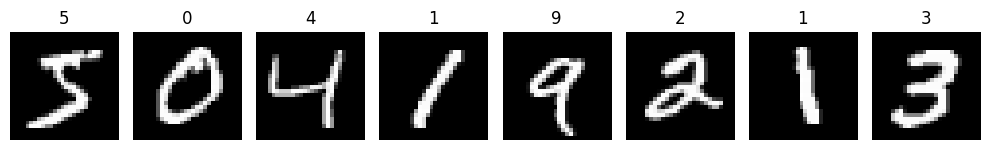

In [21]:
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for i, ax in enumerate(axes):
  img, label = train[i]
  ax.imshow(img[0], cmap='gray')
  ax.set_title(label)
  ax.axis('off')
plt.tight_layout()
plt.show()

# 2. Define Architecture

In [22]:
class CNN(nn.Module):
	def __init__(self, image_size, in_channels, out_features):
		super(CNN, self).__init__()

		self.block1 = nn.Sequential(
			nn.Conv2d(in_channels, 32, 3, padding=1),
			nn.BatchNorm2d(32),
			nn.ReLU(),
			nn.MaxPool2d(2, 2)
		)

		image_size = image_size // 2

		self.block2 = nn.Sequential(
			nn.Conv2d(32, 64, 3, padding=1),
			nn.BatchNorm2d(64),
			nn.ReLU(),
			nn.MaxPool2d(2, 2)
		)

		image_size = image_size // 2

		self.block3 = nn.Sequential(
			nn.Conv2d(64, 128, 3, padding=1),
			nn.BatchNorm2d(128),
			nn.ReLU(),
			nn.MaxPool2d(2, 2)
		)

		image_size = image_size // 2

		self.flatten = nn.Flatten()
		self.fc1 = nn.Linear(128 * image_size * image_size, 64)
		self.fc2 = nn.Linear(64, 32)
		self.fc3 = nn.Linear(32, out_features)

	def forward(self, x):
		x = self.block1(x)
		x = self.block2(x)
		x = self.block3(x)
		x = self.flatten(x)
		x = F.relu(self.fc1(x))
		x = F.relu(self.fc2(x))
		x = self.fc3(x)

		return x

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN(28, 1, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3. Train Model

In [24]:
def evaluation(dl):
    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)

            loss_sum += criterion(logits, yb).item() * len(xb)

            y_pred = torch.argmax(logits, dim=1)
            correct += (y_pred == yb).sum().item()

            total += len(xb)

    return loss_sum/total, correct/total

In [25]:
epochs = 20

learning_histories = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

for epoch in range(epochs):
    model.train()

    running_train_loss = 0.0
    running_train_correct = 0
    total_train_images = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * len(xb)
        predictions = torch.argmax(y_pred, dim=1)
        running_train_correct += (predictions == yb).sum().item()
        total_train_images += len(xb)

    tr_loss = running_train_loss / total_train_images
    tr_acc = running_train_correct / total_train_images

    te_loss, te_acc = evaluation(test_dl)

    learning_histories['train_loss'].append(tr_loss)
    learning_histories['train_acc'].append(tr_acc)
    learning_histories['test_loss'].append(te_loss)
    learning_histories['test_acc'].append(te_acc)

    print(f'Epoch {epoch + 1} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Test Loss: {te_loss:.4f} Acc: {te_acc:.4f}')

Epoch 1 | Train Loss: 0.1350 Acc: 0.9608 | Test Loss: 0.0397 Acc: 0.9888
Epoch 2 | Train Loss: 0.0392 Acc: 0.9877 | Test Loss: 0.0428 Acc: 0.9866
Epoch 3 | Train Loss: 0.0284 Acc: 0.9907 | Test Loss: 0.0255 Acc: 0.9919
Epoch 4 | Train Loss: 0.0229 Acc: 0.9929 | Test Loss: 0.0244 Acc: 0.9916
Epoch 5 | Train Loss: 0.0179 Acc: 0.9941 | Test Loss: 0.0287 Acc: 0.9922
Epoch 6 | Train Loss: 0.0165 Acc: 0.9946 | Test Loss: 0.0315 Acc: 0.9904
Epoch 7 | Train Loss: 0.0127 Acc: 0.9959 | Test Loss: 0.0314 Acc: 0.9917
Epoch 8 | Train Loss: 0.0103 Acc: 0.9965 | Test Loss: 0.0240 Acc: 0.9938
Epoch 9 | Train Loss: 0.0101 Acc: 0.9967 | Test Loss: 0.0421 Acc: 0.9891
Epoch 10 | Train Loss: 0.0086 Acc: 0.9973 | Test Loss: 0.0434 Acc: 0.9896
Epoch 11 | Train Loss: 0.0077 Acc: 0.9973 | Test Loss: 0.0376 Acc: 0.9911
Epoch 12 | Train Loss: 0.0057 Acc: 0.9982 | Test Loss: 0.0381 Acc: 0.9916
Epoch 13 | Train Loss: 0.0064 Acc: 0.9977 | Test Loss: 0.0350 Acc: 0.9916
Epoch 14 | Train Loss: 0.0056 Acc: 0.9981 | Tes

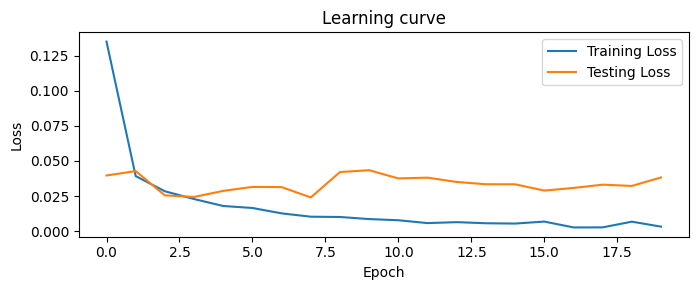

In [26]:
plt.figure(figsize=(7, 3))
plt.plot(learning_histories["train_loss"], label="Training Loss")
plt.plot(learning_histories["test_loss"], label="Testing Loss")
plt.legend()
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Learning curve")
plt.tight_layout()
plt.show()

# 4. Error Analysis

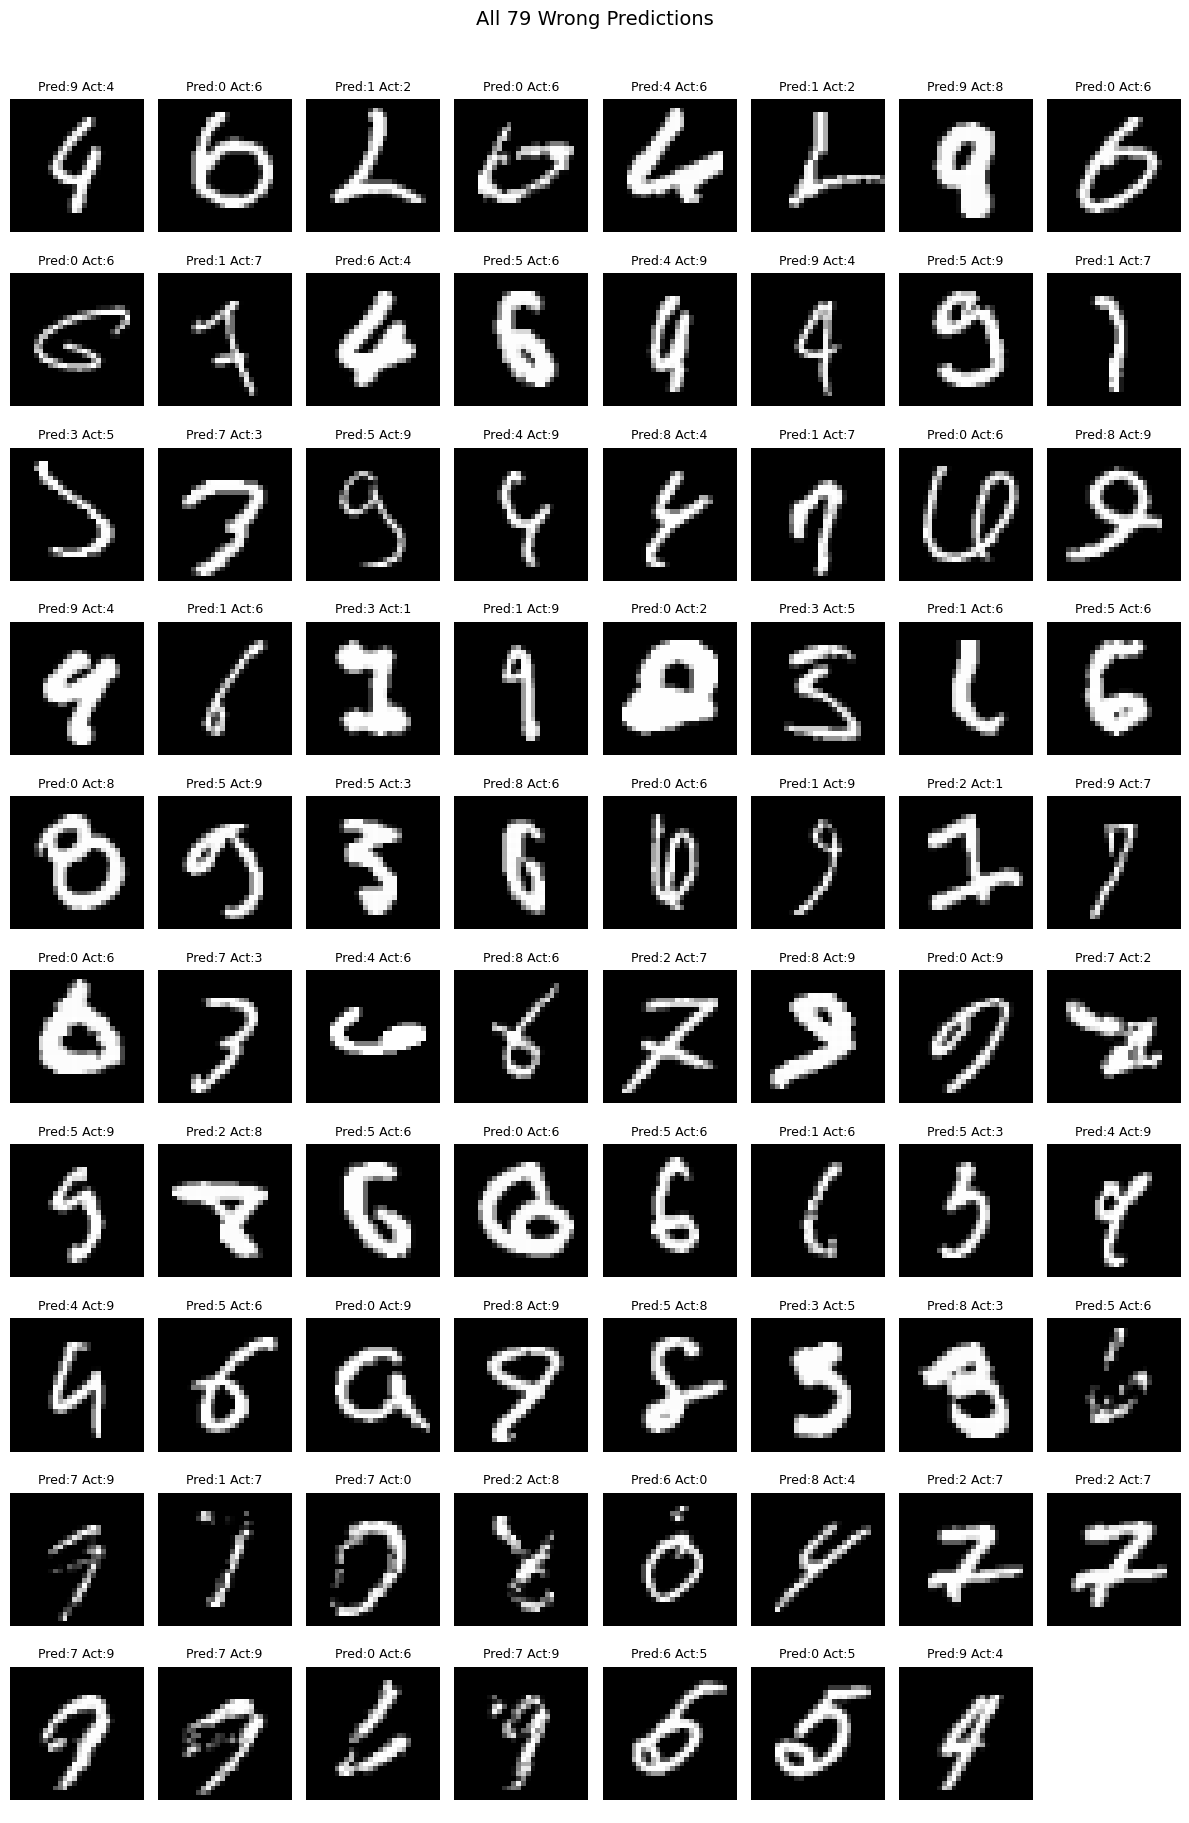

In [27]:
model.eval()
wrong_img, wrong_pred, wrong_label = [], [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb).argmax(1)
        mask = pred != yb
        wrong_img.extend(xb[mask])
        wrong_pred.extend(pred[mask].tolist())
        wrong_label.extend(yb[mask].tolist())

total_wrong = len(wrong_img)
cols = 8 # How many images wide you want the grid to be
rows = math.ceil(total_wrong / cols) # Automatically calculates required rows

# 1. Create a large, dynamic grid
fig, axes = plt.subplots(rows, cols, figsize=(12, 1.8 * rows))

# Flatten the axes array so we can easily loop through it
axes = axes.flatten()

for i in range(len(axes)):
    # 2. Plot the image if we haven't run out of wrong predictions yet
    if i < total_wrong:
        img = wrong_img[i]
        p = wrong_pred[i]
        l = wrong_label[i]

        # Move tensor to CPU and convert to numpy
        axes[i].imshow(img[0].cpu().numpy(), cmap="gray")

        # Fixed typo: changed ax.wrong_label to ax.set_title
        axes[i].set_title(f"Pred:{p} Act:{l}", fontsize=9)
        axes[i].axis("off")

    # 3. Turn off the borders for any empty slots at the end of the grid
    else:
        axes[i].axis("off")

plt.suptitle(f"All {total_wrong} Wrong Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 5. Save Model

In [28]:
torch.save(model.state_dict(), '/content/drive/MyDrive/mnist/model/model.pth')